# Momentum quintile research
Stocks are ranked by 63-trading-observation adjusted-close momentum on each formation date. Q1 is the bottom quintile and Q5 the top. Outcomes use the following 21 trading observations and are never used during ranking.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.momentum_research import build_momentum_research

prices = pd.read_parquet(ROOT / 'data/processed/price_features.parquet')
observations, summary, spread, report = build_momentum_research(prices)
summary

,quintile,observations,dates,mean_forward_return,median_forward_return,hit_rate
0,1,1688,422,0.019349,0.004850,0.526659
1,2,1688,422,0.016645,0.004013,0.513033
2,3,1688,422,0.017739,0.008432,0.545616
3,4,1688,422,0.014441,0.008067,0.544431
4,5,1688,422,0.038311,0.008096,0.530806


Text(0, 0.5, 'Forward return')

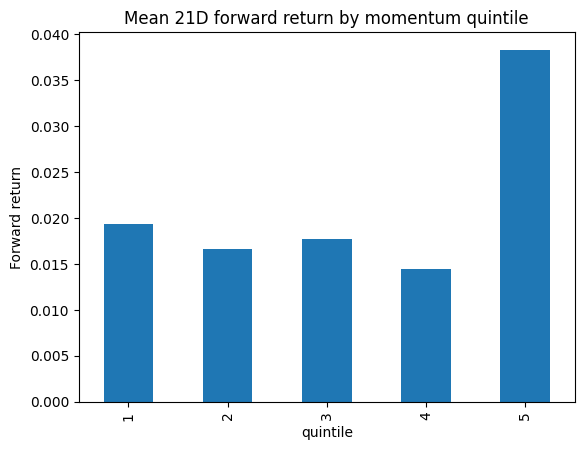

In [2]:
ax = summary.plot.bar(x='quintile', y='mean_forward_return', legend=False, title='Mean 21D forward return by momentum quintile')
ax.set_ylabel('Forward return')

In [3]:
summary[['quintile', 'observations', 'mean_forward_return', 'median_forward_return', 'hit_rate']]
report

{'momentum_window_trading_observations': 63,
 'forward_window_trading_observations': 21,
 'minimum_cross_section': 10,
 'price_basis': 'adjusted_close',
 'formation_and_forward_separation': True,
 'missing_policy': 'complete signal and forward-return rows only; no fill',
 'observations': 8440,
 'formation_dates': 422,
 'symbols': 20,
 'mean_top_minus_bottom': 0.018962195251989968,
 'median_top_minus_bottom': 0.012202794785910798,
 'positive_spread_hit_rate': 0.5545023696682464,
 'limitations': ['Current fixed 20-stock universe may introduce survivorship bias.',
  'Overlapping 21-day forward returns are descriptive and not independent bets.',
  'No transaction costs, taxes, slippage, or capacity constraints are modeled.',
  'This is educational historical research, not an investment recommendation.']}

## Interpretation limits
The fixed 20-stock universe may have survivorship bias. Forward windows overlap, observations are not independent, and costs are omitted. Results are descriptive educational evidence—not a trading recommendation.